In [ ]:
#Import required libraries
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, model_selection

import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.models import resnet18

# Set the device to GPU if available, otherwise use CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on device:", DEVICE.upper())

# Set a manual random seed for dataset partitioning to ensure reproducibility
RNG = torch.Generator().manual_seed(42)

Running on device: CUDA


In [ ]:
# Define normalization transformation for CIFAR-10 dataset
normalize = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

# Download and load the CIFAR-10 training dataset
train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=normalize
)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2)

# Download and load the CIFAR-10 test dataset
held_out = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=normalize
)

# Split the held-out dataset into test and validation sets
# Using manual seed ensures reproducibility in the split
test_set, val_set = torch.utils.data.random_split(held_out, [0.5, 0.5], generator=RNG)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=2)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=2)

# Download the indices of the forget set and retain set from an external source
local_path = "forget_idx.npy"
if not os.path.exists(local_path):
    response = requests.get(
        "https://storage.googleapis.com/unlearning-challenge/" + local_path
    )
    open(local_path, "wb").write(response.content)
forget_idx = np.load(local_path)


# Create a boolean mask to separate forget and retain indices
forget_mask = np.zeros(len(train_set.targets), dtype=bool)
forget_mask[forget_idx] = True
retain_idx = np.arange(forget_mask.size)[~forget_mask]

# Split the training set into a forget set and a retain set
forget_set = torch.utils.data.Subset(train_set, forget_idx)
retain_set = torch.utils.data.Subset(train_set, retain_idx)

# Create DataLoaders for the forget and retain sets
forget_loader = torch.utils.data.DataLoader(
    forget_set, batch_size=128, shuffle=True, num_workers=2
)
retain_loader = torch.utils.data.DataLoader(
    retain_set, batch_size=128, shuffle=True, num_workers=2, generator=RNG
)

100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
# Download pre-trained ResNet-18 model weights if not already present
local_path = "weights_resnet18_cifar10.pth"
if not os.path.exists(local_path):
    response = requests.get(
        "https://storage.googleapis.com/unlearning-challenge/weights_resnet18_cifar10.pth"
    )
    open(local_path, "wb").write(response.content)

# Load the pre-trained weights
weights_pretrained = torch.load(local_path, map_location=DEVICE)

# Initialize a ResNet-18 model with the correct number of output classes
model = resnet18(weights=None, num_classes=10)

# Load the pre-trained weights into the model
model.load_state_dict(weights_pretrained)

#Move the model to the selected device (GPU/CPU) and set it to evaluation mode
model.to(DEVICE)
model.eval();

<ipython-input-3-7724b2c0895c>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_pretrained = torch.load(local_path, map_location=DEVICE)


Files already downloaded and verified


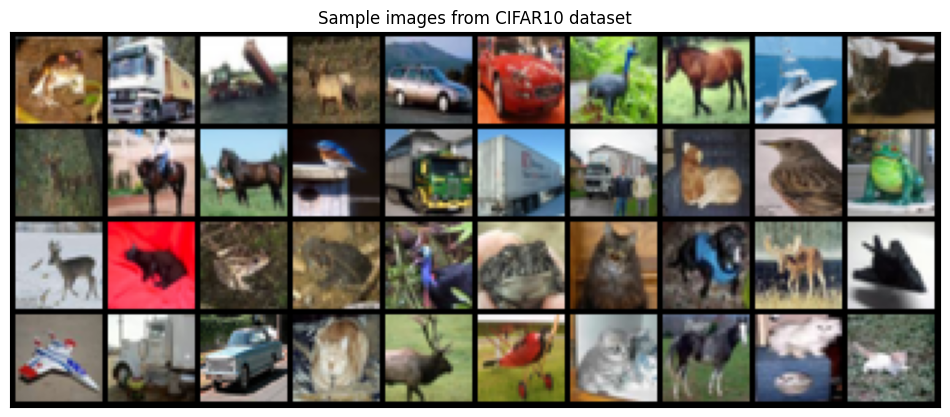

In [ ]:
# Create a temporary DataLoader without normalization to visualize CIFAR-10 images
tmp_dl = DataLoader(
    torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transforms.ToTensor()
    ),
    batch_size=10 * 4,
    shuffle=False,
)

# Retrieve a batch of images and labels
images, labels = next(iter(tmp_dl))

# Display sample images from the CIFAR-10 dataset
fig, ax = plt.subplots(figsize=(12, 6))
plt.title("Sample images from CIFAR10 dataset")
ax.set_xticks([])
ax.set_yticks([])
ax.imshow(make_grid(images, nrow=10).permute(1, 2, 0))
plt.show()

In [ ]:
# Function to compute accuracy of a model on a given dataset
def accuracy(net, loader):
    """Return accuracy on a dataset given by the data loader."""
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = net(inputs)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return correct / total

# Print accuracy on training and test datasets
print(f"Train set accuracy: {100.0 * accuracy(model, train_loader):0.1f}%")
print(f"Test set accuracy: {100.0 * accuracy(model, test_loader):0.1f}%")

Train set accuracy: 99.5%
Test set accuracy: 88.3%


In [ ]:
# Function to perform unlearning by fine-tuning the model
def unlearning(net, retain, forget, validation):
    """Unlearning by fine-tuning.

    Fine-tuning is a very simple algorithm that trains using only
    the retain set.

    Args:
      net : nn.Module.
        pre-trained model to use as base of unlearning.
      retain : torch.utils.data.DataLoader.
        Dataset loader for access to the retain set. This is the subset
        of the training set that we don't want to forget.
      forget : torch.utils.data.DataLoader.
        Dataset loader for access to the forget set. This is the subset
        of the training set that we want to forget. This method doesn't
        make use of the forget set.
      validation : torch.utils.data.DataLoader.
        Dataset loader for access to the validation set. This method doesn't
        make use of the validation set.
    Returns:
      net : updated model
    """
    epochs = 5

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    net.train()

    for _ in range(epochs):
        for inputs, targets in retain:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        scheduler.step()

    net.eval()
    return net

# Fine-tune the model using only the retain set
ft_model = resnet18(weights=None, num_classes=10)
ft_model.load_state_dict(weights_pretrained)
ft_model.to(DEVICE)
ft_model = unlearning(ft_model, retain_loader, forget_loader, test_loader)

# Print accuracy after unlearning
print(f"Retain set accuracy: {100.0 * accuracy(ft_model, retain_loader):0.1f}%")
print(f"Test set accuracy: {100.0 * accuracy(ft_model, test_loader):0.1f}%")

Retain set accuracy: 98.5%
Test set accuracy: 84.0%


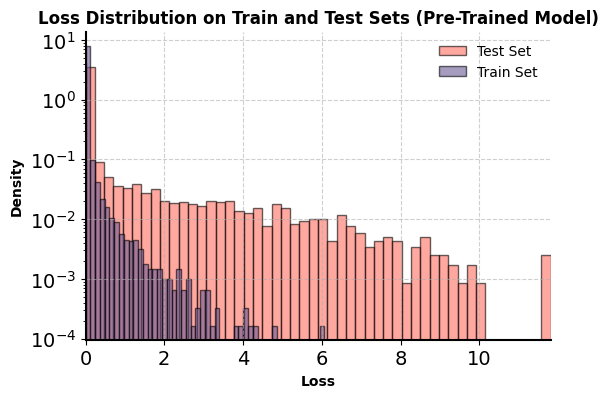

In [ ]:
# Function to compute per-sample loss
def compute_losses(net, loader):
    """Auxiliary function to compute per-sample losses"""

    criterion = nn.CrossEntropyLoss(reduction="none")
    all_losses = []

    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        logits = net(inputs)
        losses = criterion(logits, targets).numpy(force=True)
        for l in losses:
            all_losses.append(l)

    return np.array(all_losses)

# Compute losses for training and test sets
train_losses = compute_losses(model, train_loader)
test_losses = compute_losses(model, test_loader)

#Visualize the losses

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 4))  # Increase the figure size

# Set title with a larger font size and bold font weight
plt.title("Loss Distribution on Train and Test Sets (Pre-Trained Model)", fontsize=12, fontweight='bold')

# Use a more appealing color palette for the histograms
plt.hist(test_losses, density=True, alpha=0.6, bins=50, label="Test Set", color="#FF6F61", edgecolor='black')
plt.hist(train_losses, density=True, alpha=0.6, bins=50, label="Train Set", color="#6B5B95", edgecolor='black')

# Set labels with a larger font size and font weight
plt.xlabel("Loss", fontsize=10, fontweight='bold')
plt.ylabel("Density", fontsize=10, fontweight='bold')

# Set limits and scales
plt.xlim((0, np.max(test_losses)))
plt.yscale("log")

# Enhance the legend
plt.legend(frameon=False, fontsize=10, loc='upper right')

# Customize the axes' appearance
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14)

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
#Computes cross-validation score of a membership inference attack.
def simple_mia(sample_loss, members, n_splits=10, random_state=0):
    """
    Args:
      sample_loss : array_like of shape (n,).
        objective function evaluated on n samples.
      members : array_like of shape (n,),
        whether a sample was used for training.
      n_splits: int
        number of splits to use in the cross-validation.
    Returns:
      scores : array_like of size (n_splits,)
    """
    # Ensure that the members array contains only 0s and 1s
    unique_members = np.unique(members)
    if not np.all(unique_members == np.array([0, 1])):
        raise ValueError("members should only have 0 and 1s")

    # Define logistic regression attack model
    attack_model = linear_model.LogisticRegression()

    # Use stratified shuffle split for cross-validation
    cv = model_selection.StratifiedShuffleSplit(
        n_splits=n_splits, random_state=random_state
    )

    # Compute cross-validation scores
    return model_selection.cross_val_score(
        attack_model, sample_loss, members, cv=cv, scoring="accuracy"
    )

# Compute per-sample losses for the forget set
forget_losses = compute_losses(model, forget_loader)

# Sub-sample forget losses to match the number of test losses for class balance to have a class-balanced dataset.
np.random.shuffle(forget_losses)
forget_losses = forget_losses[: len(test_losses)]

# Combine test and forget losses to form the dataset for MIA attack
samples_mia = np.concatenate((test_losses, forget_losses)).reshape((-1, 1))
labels_mia = [0] * len(test_losses) + [1] * len(forget_losses)

# Evaluate the attack model on the original model
mia_scores = simple_mia(samples_mia, labels_mia)

# Print MIA accuracy on forgotten vs unseen images
print(
    f"The MIA has an accuracy of {mia_scores.mean():.3f} on forgotten vs unseen images"
)

The MIA has an accuracy of 0.579 on forgotten vs unseen images


In [ ]:
# Compute per-sample losses for the forget and test sets on the fine-tuned model
ft_forget_losses = compute_losses(ft_model, forget_loader)
ft_test_losses = compute_losses(ft_model, test_loader)

# Ensure we have a balanced dataset by asserting equal sample sizes
assert len(ft_test_losses) == len(ft_forget_losses)

# Combine test and forget losses to form the dataset for MIA attack on fine-tuned model
ft_samples_mia = np.concatenate((ft_test_losses, ft_forget_losses)).reshape((-1, 1))
labels_mia = [0] * len(ft_test_losses) + [1] * len(ft_forget_losses)

# Evaluate the attack model on the fine-tuned model
ft_mia_scores = simple_mia(ft_samples_mia, labels_mia)

# Print MIA accuracy after unlearning
print(
    f"The MIA has an accuracy of {ft_mia_scores.mean():.3f} on forgotten vs unseen images"
)

The MIA has an accuracy of 0.507 on forgotten vs unseen images


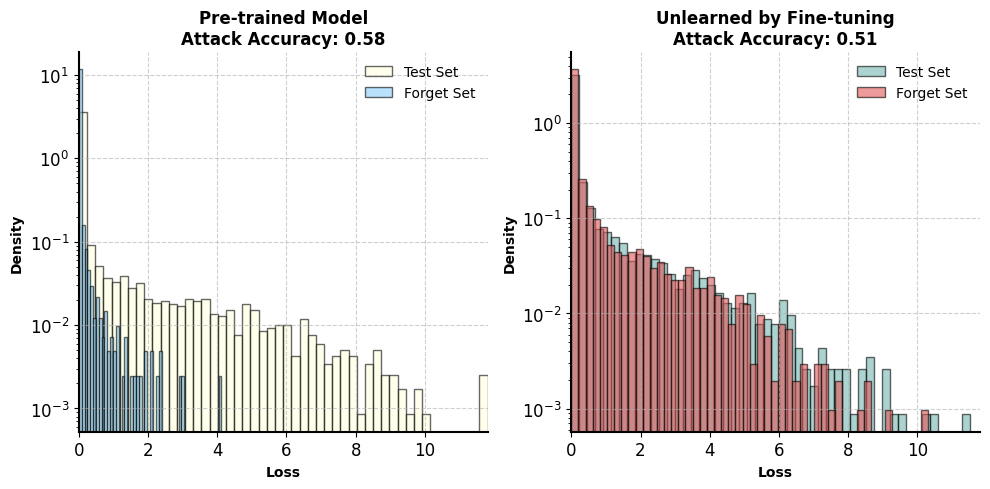

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # Slightly larger figure for better visibility

# Set titles with larger font size and bold font weight
ax1.set_title(f"Pre-trained Model\nAttack Accuracy: {mia_scores.mean():0.2f}", fontsize=12, fontweight='bold')
ax2.set_title(f"Unlearned by Fine-tuning\nAttack Accuracy: {ft_mia_scores.mean():0.2f}", fontsize=12, fontweight='bold')

# Use a more appealing color palette and add edge color to histograms
ax1.hist(test_losses, density=True, alpha=0.6, bins=50, label="Test Set", color="lightyellow", edgecolor='black')
ax1.hist(forget_losses, density=True, alpha=0.6, bins=50, label="Forget Set", color="lightskyblue", edgecolor='black')

ax2.hist(ft_test_losses, density=True, alpha=0.6, bins=50, label="Test Set", color="#76B7B2", edgecolor='black')
ax2.hist(ft_forget_losses, density=True, alpha=0.6, bins=50, label="Forget Set", color="#E15759", edgecolor='black')

# Set labels with larger font size and bold font weight
ax1.set_xlabel("Loss", fontsize=10, fontweight='bold')
ax2.set_xlabel("Loss", fontsize=10, fontweight='bold')
ax1.set_ylabel("Density", fontsize=10, fontweight='bold')  # Adjusted from "Frequency" to "Density" for consistency
ax2.set_ylabel("Density", fontsize=10, fontweight='bold')

# Set logarithmic scale for y-axis
ax1.set_yscale("log")
ax2.set_yscale("log")

# Set x-axis limits
ax1.set_xlim((0, np.max(test_losses)))
ax2.set_xlim((0, np.max(test_losses)))

# Customize the axes' appearance
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)  # Add a subtle grid for better readability

# Enhance the legend
ax1.legend(frameon=False, fontsize=10)
ax2.legend(frameon=False, fontsize=10)

# Improve spacing between plots
plt.tight_layout()
plt.show()

In [ ]:
# Download weights of a model trained exclusively on the retain set
local_path = "retrain_weights_resnet18_cifar10.pth"
if not os.path.exists(local_path):
    response = requests.get(
        "https://storage.googleapis.com/unlearning-challenge/" + local_path
    )
    open(local_path, "wb").write(response.content)

# Load pre-trained weights of the retrained model
weights_pretrained = torch.load(local_path, map_location=DEVICE)

# Initialize and load the retrained model
rt_model = resnet18(weights=None, num_classes=10)
rt_model.load_state_dict(weights_pretrained)
rt_model.to(DEVICE)
rt_model.eval()

# Print accuracy of the retrained model on retain and forget sets
print(f"Retain set accuracy: {100.0 * accuracy(rt_model, retain_loader):0.1f}%")
print(f"Forget set accuracy: {100.0 * accuracy(rt_model, forget_loader):0.1f}%")

<ipython-input-11-05ade7f0094d>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_pretrained = torch.load(local_path, map_location=DEVICE)


Retain set accuracy: 99.5%
Forget set accuracy: 88.2%


In [ ]:
# Compute per-sample losses for the test and forget sets on the retrained model
rt_test_losses = compute_losses(rt_model, test_loader)
rt_forget_losses = compute_losses(rt_model, forget_loader)

# Combine test and forget losses for MIA on retrained model
rt_samples_mia = np.concatenate((rt_test_losses, rt_forget_losses)).reshape((-1, 1))
labels_mia = [0] * len(rt_test_losses) + [1] * len(rt_forget_losses)

# Evaluate the attack model on the retrained model
rt_mia_scores = simple_mia(rt_samples_mia, labels_mia)

# Print MIA accuracy on the retrained model
print(
    f"The MIA has an accuracy of {rt_mia_scores.mean():.3f} on forgotten vs unseen images"
)

The MIA has an accuracy of 0.497 on forgotten vs unseen images


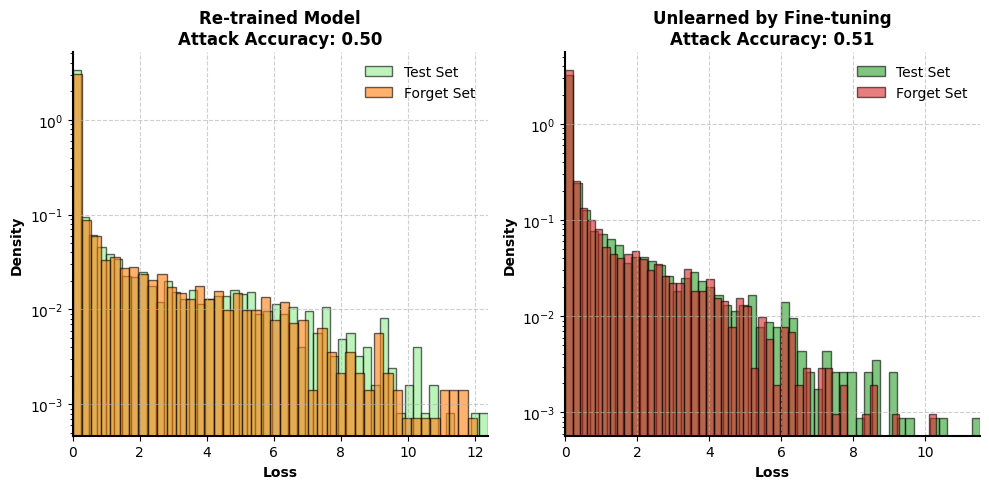

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # Slightly larger figure for better visibility

# Set titles with larger font size and bold font weight
ax1.set_title(f"Re-trained Model\nAttack Accuracy: {rt_mia_scores.mean():0.2f}", fontsize=12, fontweight='bold')
ax2.set_title(f"Unlearned by Fine-tuning\nAttack Accuracy: {ft_mia_scores.mean():0.2f}", fontsize=12, fontweight='bold')

# Use a more appealing color palette and add edge color to histograms
ax1.hist(rt_test_losses, density=True, alpha=0.6, bins=50, label="Test Set", color="lightgreen", edgecolor='black')
ax1.hist(rt_forget_losses, density=True, alpha=0.6, bins=50, label="Forget Set", color="#FF7F0E", edgecolor='black')

ax2.hist(ft_test_losses, density=True, alpha=0.6, bins=50, label="Test Set", color="#2CA02C", edgecolor='black')
ax2.hist(ft_forget_losses, density=True, alpha=0.6, bins=50, label="Forget Set", color="#D62728", edgecolor='black')

# Set labels with larger font size and bold font weight
ax1.set_xlabel("Loss", fontsize=10, fontweight='bold')
ax2.set_xlabel("Loss", fontsize=10, fontweight='bold')
ax1.set_ylabel("Density", fontsize=10, fontweight='bold')  # Adjusted from "Frequency" to "Density" for consistency
ax2.set_ylabel("Density", fontsize=10, fontweight='bold')

# Set logarithmic scale for y-axis
ax1.set_yscale("log")
ax2.set_yscale("log")

# Set x-axis limits
ax1.set_xlim((0, np.max(rt_test_losses)))
ax2.set_xlim((0, np.max(ft_test_losses)))

# Customize the axes' appearance
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)  # Add a subtle grid for better readability

# Enhance the legend
ax1.legend(frameon=False, fontsize=10)
ax2.legend(frameon=False, fontsize=10)

plt.tight_layout()  # Improve spacing between plots
plt.show()


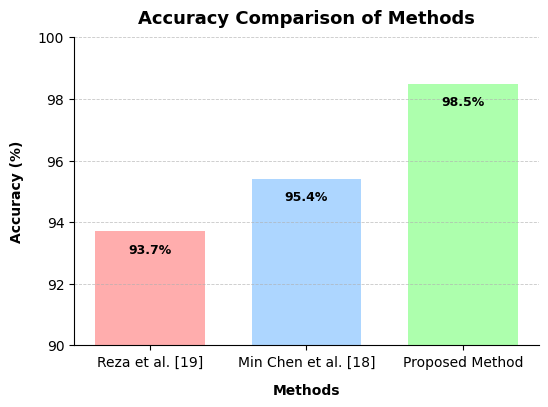

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = ["Reza et al. [19]", "Min Chen et al. [18]", "Proposed Method"]
accuracy = [93.7, 95.4, 98.5]
colors = ["#ff9999", "#99ccff", "#99ff99"]  # Light red, blue, green

# Create figure and axis
plt.figure(figsize=(6, 4))

# Create bars with edge and transparency
bars = plt.bar(methods, accuracy, color=colors, alpha=0.8, linewidth=2, width=0.7)

# Add accuracy labels inside the bars
for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.8, f"{acc}%",
             ha="center", va="bottom", fontsize=9, fontweight="bold", color="black")

# Labels and title styling
plt.xlabel("Methods", fontsize=10, fontweight="bold", labelpad=10)
plt.ylabel("Accuracy (%)", fontsize=10, fontweight="bold", labelpad=10)
plt.title("Accuracy Comparison of Methods", fontsize=13, fontweight="bold", pad=10)

# Set y-axis range for better visibility
plt.ylim(90, 100)

# Gridlines with a subtle style
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.7)

# Remove top and right spines for a cleaner look
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Show the plot
plt.show()
